# Phase 2: Behavioral Segmentation (RFM Framework)

**Goal:** Move past simple filtering and mathematically group customers by value, using Recency, Frequency, and Monetary (RFM) metrics and unsupervised clustering.

**Input:** `cleaned_online_retail.parquet` — the cleaned, transaction-level output of Phase 1.

**Output:** A customer-level table with an assigned business segment and additional features needed for Phase 3 (churn modeling), saved to disk for the next notebook to load.

This notebook covers:
1. RFM feature engineering
2. Preprocessing (log transform + scaling)
3. Model exploration & validation — K-Means, GMM, and Hierarchical clustering compared head-to-head
4. Model decision — which one ships, and why
5. Business segment labeling + additional features for Phase 3
6. Saving the processed output

> Run top-to-bottom (`Kernel → Restart & Run All`) before committing — see the Phase 1 notebook for why this matters.


## Setup

In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]


## Step 1: Load Cleaned Data

In [89]:
df = pd.read_parquet('cleaned_online_retail.parquet')
print(f"Loaded {df.shape[0]:,} transaction rows for {df['CustomerID'].nunique():,} unique customers.")


Loaded 390,565 transaction rows for 4,317 unique customers.


## Step 2: RFM Feature Engineering

- **Recency:** days between a customer's last purchase and the snapshot date
- **Frequency:** number of distinct invoices (shopping trips, not items)
- **Monetary:** total revenue generated

The snapshot date is set to 1 day *after* the dataset's last transaction — if it were set to the last transaction date itself, the most recent buyers would get `Recency = 0`, which breaks the log transform in Step 3 (`log(0)` is undefined).

In [91]:
# Establish the snapshot date (1 day after the dataset's max date — see rationale above)
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Aggregate at the customer level. Named aggregation avoids multi-index columns.
rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),   # distinct shopping trips, not items bought
    Monetary=('TotalRevenue', 'sum')
).reset_index()

# Defensive check: customers with net-negative or zero monetary value (returns > purchases)
# can't be log-transformed in Step 3. Given Phase 1 already removed negative-quantity/price
# rows, this should rarely trigger — kept here as a safety net rather than an assumption.
before = rfm.shape[0]
rfm = rfm[rfm['Monetary'] > 0].copy()
print(f"Dropped {before - rfm.shape[0]} customers with non-positive Monetary value.")


Dropped 0 customers with non-positive Monetary value.


In [92]:
print(f"RFM Matrix Shape: {rfm.shape}")
display(rfm.describe())


RFM Matrix Shape: (4317, 4)


,Recency,Frequency,Monetary
count,4317.000000,4317.000000,4317.000000
mean,92.546213,4.234885,1860.301721
std,99.965817,7.603134,7585.407866
min,1.000000,1.000000,2.900000
25%,18.000000,1.000000,300.050000
50%,51.000000,2.000000,655.580000
75%,143.000000,5.000000,1610.150000
max,374.000000,206.000000,264139.260000


## Step 3: Preprocessing

**Log transform:** RFM features are heavily right-skewed (a handful of high-value/high-frequency customers). Log-transforming compresses that skew before scaling.

**Standard scaling:** K-Means (and GMM, via Euclidean/Mahalanobis-style distances) are sensitive to feature scale — without this, Monetary (values in the thousands) would dominate Recency/Frequency (values in the tens) purely because of units, not actual importance.

In [94]:
features = ['Recency', 'Frequency', 'Monetary']

# Log transform (safe: Step 2's Monetary > 0 filter guarantees no log(0)/log(negative) errors)
rfm_log = np.log(rfm[features])

# Z-score scaling
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=features, index=rfm.index)


## Step 4: Model Exploration & Validation

Three clustering approaches are evaluated here to determine which best fits this dataset's actual geometry, rather than assuming one upfront.

### 4.1 K-Means & GMM — Hyperparameter Tuning

Both are tuned in the same loop since they're evaluated over the same `k` range:
- **K-Means:** Elbow method (inertia) + Silhouette score
- **GMM:** BIC/AIC (GMM has no "inertia," so elbow doesn't apply — lower BIC/AIC is better, the opposite direction from silhouette)

`covariance_type='full'` lets each GMM cluster take its own elliptical shape/orientation — this is the actual mechanism that would let GMM outperform K-Means *if* this dataset's clusters are elongated or overlapping rather than roughly spherical.

Evaluating clustering metrics across hyperparameter space...


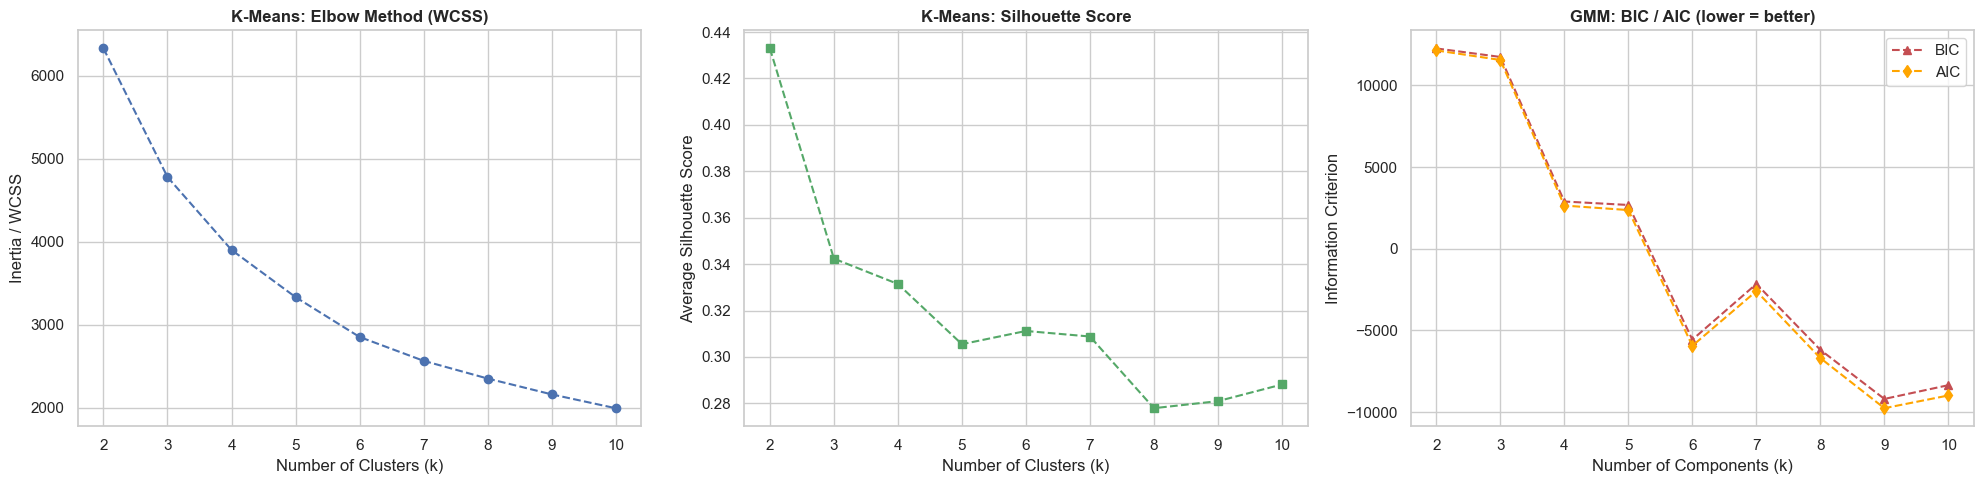

In [97]:
inertia_values = []
silhouette_scores_km = []
bic_scores = []
aic_scores = []
k_range = range(2, 11)

print("Evaluating clustering metrics across hyperparameter space...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores_km.append(silhouette_score(rfm_scaled_df, kmeans.labels_))

    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42, n_init=10)
    gmm.fit(rfm_scaled_df)
    bic_scores.append(gmm.bic(rfm_scaled_df))
    aic_scores.append(gmm.aic(rfm_scaled_df))

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].plot(k_range, inertia_values, marker='o', color='b', linestyle='--')
ax[0].set_title('K-Means: Elbow Method (WCSS)', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Number of Clusters (k)')
ax[0].set_ylabel('Inertia / WCSS')
ax[0].set_xticks(k_range)

ax[1].plot(k_range, silhouette_scores_km, marker='s', color='g', linestyle='--')
ax[1].set_title('K-Means: Silhouette Score', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Number of Clusters (k)')
ax[1].set_ylabel('Average Silhouette Score')
ax[1].set_xticks(k_range)

ax[2].plot(k_range, bic_scores, marker='^', color='r', linestyle='--', label='BIC')
ax[2].plot(k_range, aic_scores, marker='d', color='orange', linestyle='--', label='AIC')
ax[2].set_title('GMM: BIC / AIC (lower = better)', fontsize=12, fontweight='bold')
ax[2].set_xlabel('Number of Components (k)')
ax[2].set_ylabel('Information Criterion')
ax[2].set_xticks(k_range)
ax[2].legend()

plt.tight_layout()
plt.show()


### 4.2 Hierarchical Clustering — Geometric Cross-Check

An independent, distance-based view of the same scaled RFM space, using Ward linkage to minimize within-cluster variance.

Generating Hierarchical Dendrogram for geometric validation...


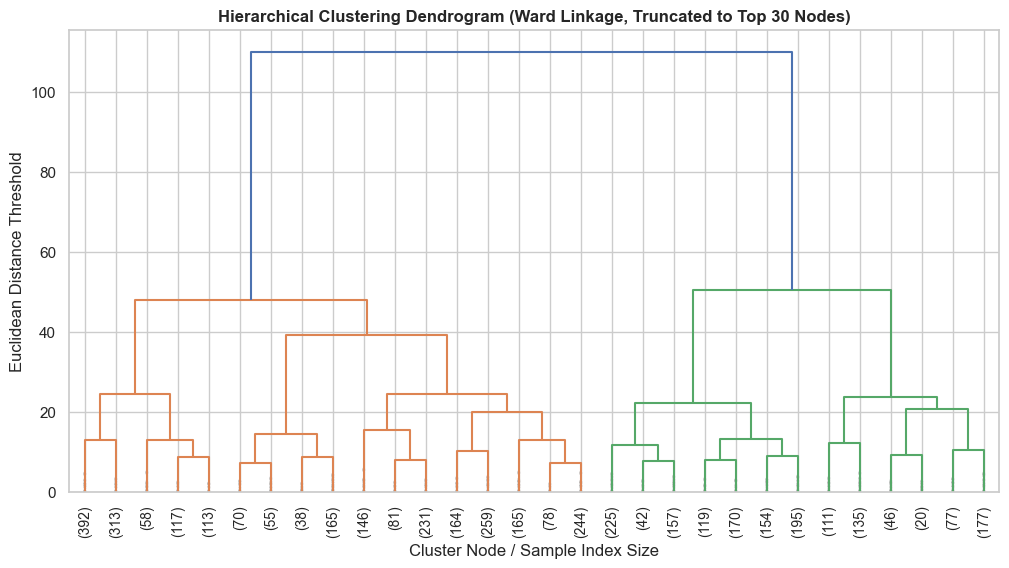

In [99]:
print("Generating Hierarchical Dendrogram for geometric validation...")
plt.figure(figsize=(12, 6))
linkage_matrix = linkage(rfm_scaled_df, method='ward')
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage, Truncated to Top 30 Nodes)', fontsize=12, fontweight='bold')
plt.xlabel('Cluster Node / Sample Index Size')
plt.ylabel('Euclidean Distance Threshold')
plt.show()


### 4.3 Head-to-Head Comparison


In [101]:
optimal_k = 4  # See Step 5 for why 4 was chosen over the statistically higher silhouette at k=2

print(f"Fitting final production candidates with optimal_k = {optimal_k}...")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['KMeans_Cluster'] = final_kmeans.fit_predict(rfm_scaled_df)

final_hierarchical = AgglomerativeClustering(n_clusters=optimal_k, metric='euclidean', linkage='ward')
rfm['Hierarchical_Cluster'] = final_hierarchical.fit_predict(rfm_scaled_df)

# GMM: capture both the hard label and the soft probability. GMM_Confidence indicates how
# sure the model is about each customer's segment — a signal K-Means/Hierarchical can't give.
final_gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=42, n_init=10)
final_gmm.fit(rfm_scaled_df)
rfm['GMM_Cluster'] = final_gmm.predict(rfm_scaled_df)
rfm['GMM_Confidence'] = final_gmm.predict_proba(rfm_scaled_df).max(axis=1)


Fitting final production candidates with optimal_k = 4...


--- Production Validation Summary (higher silhouette = better) ---
K-Means Silhouette:      0.3314
Hierarchical Silhouette: 0.2329
GMM Silhouette:          0.2029

GMM BIC @ k=4: 2894.0  (compare against the BIC/AIC curve in 4.1 — lower is better)
GMM AIC @ k=4: 2645.6

Avg GMM segment confidence: 93.75%

(2D PCA view explains 94.2% of total variance — a visual aid, not the modeling space)


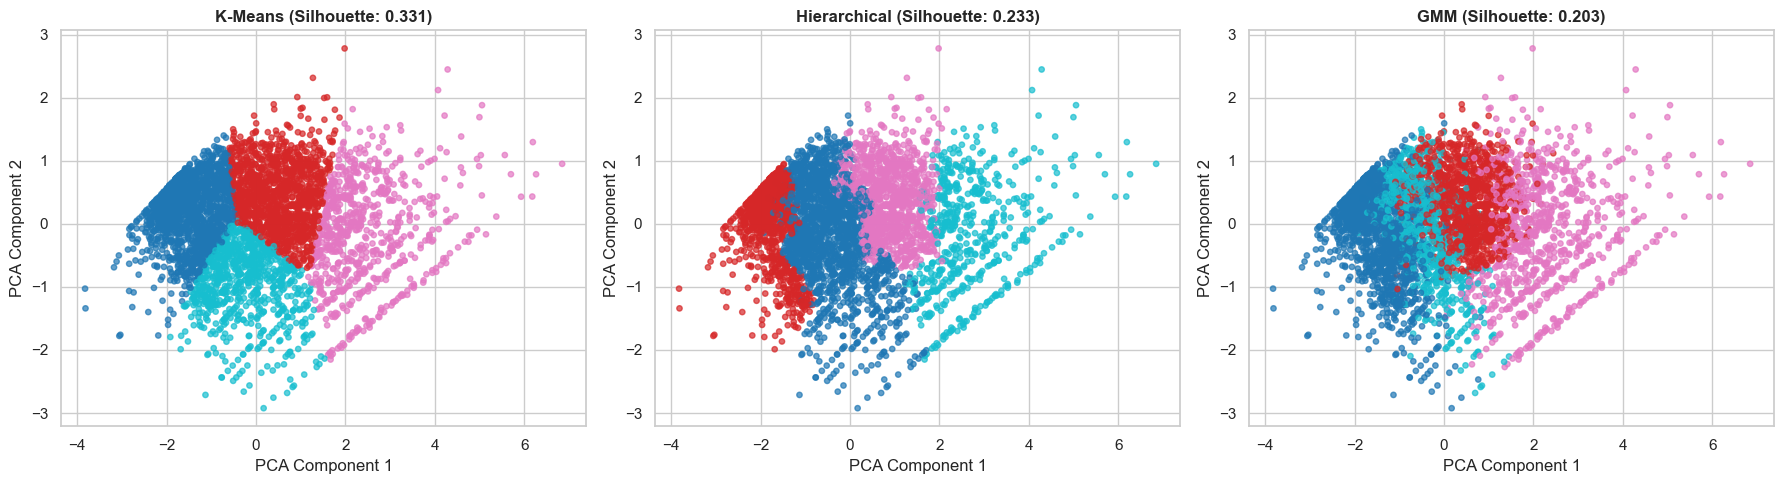

In [102]:
km_sil = silhouette_score(rfm_scaled_df, rfm['KMeans_Cluster'])
hc_sil = silhouette_score(rfm_scaled_df, rfm['Hierarchical_Cluster'])
gmm_sil = silhouette_score(rfm_scaled_df, rfm['GMM_Cluster'])

print("--- Production Validation Summary (higher silhouette = better) ---")
print(f"K-Means Silhouette:      {km_sil:.4f}")
print(f"Hierarchical Silhouette: {hc_sil:.4f}")
print(f"GMM Silhouette:          {gmm_sil:.4f}")
print(f"\nGMM BIC @ k={optimal_k}: {final_gmm.bic(rfm_scaled_df):.1f}  (compare against the BIC/AIC curve in 4.1 — lower is better)")
print(f"GMM AIC @ k={optimal_k}: {final_gmm.aic(rfm_scaled_df):.1f}")
print(f"\nAvg GMM segment confidence: {rfm['GMM_Confidence'].mean():.2%}")

pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled_df)
print(f"\n(2D PCA view explains {pca.explained_variance_ratio_.sum():.1%} of total variance — a visual aid, not the modeling space)")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title in zip(
    axes,
    ['KMeans_Cluster', 'Hierarchical_Cluster', 'GMM_Cluster'],
    ['K-Means', 'Hierarchical', 'GMM']
):
    ax.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=rfm[col], cmap='tab10', s=15, alpha=0.7)
    ax.set_title(f'{title} (Silhouette: {silhouette_score(rfm_scaled_df, rfm[col]):.3f})', fontweight='bold')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
plt.tight_layout()
plt.show()


## Step 5: Model Decision

**K-Means (k=4) is selected as the production segmentation model.**

- **Silhouette score:** K-Means (0.3314) outperformed Hierarchical (0.2329) and GMM (0.2029) by a decisive margin — not a close call.
- **Visual check (PCA projection):** K-Means produced the most distinctly separated clusters of the three. GMM showed the most color-overlap, particularly in the dense mid-value customer region — evidence that this dataset's RFM clusters are closer to spherical than elliptical, which favors K-Means's assumptions rather than GMM's added flexibility.
- **GMM's own criterion doesn't rescue it either:** BIC/AIC trend downward toward higher k (non-monotonically, with a bump around k=6–7) rather than favoring k=4 — meaning GMM's natural complexity doesn't even align with the k=4 the business needs. That's a second, independent reason GMM underperforms here, not just an artifact of forcing a shared k for comparison.
- **Why k=4 instead of the statistically higher silhouette at k=2:** silhouette actually peaks at k=2 (~0.43), but 2 segments is too coarse to support actionable business labels (Champions / At-Risk / Hibernating / New Customers, per the project's original scope). k=4 is a deliberate trade-off between statistical tightness and business interpretability, not an oversight.

GMM and Hierarchical are retained above as a documented validation trail, not because they were close contenders.

## Step 6: Finalize Production Segmentation

### 6.1 Profile Clusters & Assign Business Labels

In [106]:
cluster_profile = rfm.groupby('KMeans_Cluster')[features].mean().round(1)
cluster_profile['CustomerCount'] = rfm['KMeans_Cluster'].value_counts()
display(cluster_profile.sort_values('Monetary', ascending=False))


,Recency,Frequency,Monetary,CustomerCount
KMeans_Cluster,,,,
2,10.1,13.0,7014.9,740
1,70.0,4.2,1560.8,1264
3,21.6,1.9,457.4,797
0,188.9,1.3,331.5,1516


In [107]:

segment_map = {
    0: 'Hibernating',
    1: 'At Risk',
    2: 'Champions',
    3: 'New Customers',
}

rfm['Segment'] = rfm['KMeans_Cluster'].map(segment_map)

assert rfm['Segment'].isnull().sum() == 0, "segment_map is missing an entry for at least one cluster ID — check the mapping above."
rfm['Segment'].value_counts()


Segment
Hibernating      1516
At Risk          1264
New Customers     797
Champions         740
Name: count, dtype: int64

### 6.2 Additional Features for Phase 3 Handoff

Phase 3's churn model needs more than RFM alone — per the project roadmap, it also needs **average order value**, **variety of items bought**, and **cohort age**. None of these exist yet, so they're added here rather than being discovered as a gap mid-way through Phase 3.

In [109]:
# Average order value: spend per shopping trip (safe to divide — Frequency is always >= 1
# by construction, since every customer in `rfm` has at least one transaction)
rfm['AvgOrderValue'] = rfm['Monetary'] / rfm['Frequency']

# Item variety: distinct products purchased (requires joining back to the transaction-level df)
item_variety = df.groupby('CustomerID')['StockCode'].nunique().rename('ItemVariety')
rfm = rfm.merge(item_variety, on='CustomerID', how='left')

# Cohort age: customer tenure in days (snapshot date minus first purchase date)
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min().rename('FirstPurchaseDate')
rfm = rfm.merge(first_purchase, on='CustomerID', how='left')
rfm['CohortAge_Days'] = (snapshot_date - rfm['FirstPurchaseDate']).dt.days
rfm = rfm.drop(columns=['FirstPurchaseDate'])

rfm[['CustomerID', 'AvgOrderValue', 'ItemVariety', 'CohortAge_Days']].head()


,CustomerID,AvgOrderValue,ItemVariety,CohortAge_Days
0,12347,615.714286,103,367
1,12348,359.310000,21,358
2,12349,1457.550000,72,19
3,12350,294.400000,16,310
4,12352,197.962857,57,297


### 6.3 Finalize Columns for Export

- `Hierarchical_Cluster` and `GMM_Cluster` are dropped — they were validation evidence for the Step 5 decision, not competing production labels. Carrying multiple unreconciled "segment" columns forward would make it unclear which one Phase 3 is supposed to trust.
- `GMM_Confidence` is kept intentionally, not "just in case" — it's carried forward as a candidate feature for Phase 3's churn model, since a customer GMM is genuinely unsure about (sitting near a segment boundary) plausibly behaves differently than one it's 95%+ confident about. Drop this column later if Phase 3 ends up not using it.

In [111]:
final_columns = [
    'CustomerID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
    'ItemVariety', 'CohortAge_Days', 'KMeans_Cluster', 'Segment', 'GMM_Confidence'
]
rfm_final = rfm[final_columns].copy()

print(f"Final handoff table: {rfm_final.shape[0]:,} customers x {rfm_final.shape[1]} columns")
rfm_final.head()


Final handoff table: 4,317 customers x 10 columns


,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,ItemVariety,CohortAge_Days,KMeans_Cluster,Segment,GMM_Confidence
0,12347,2,7,4310.00,615.714286,103,367,2,Champions,0.982968
1,12348,75,4,1437.24,359.310000,21,358,1,At Risk,0.943706
2,12349,19,1,1457.55,1457.550000,72,19,3,New Customers,0.999999
3,12350,310,1,294.40,294.400000,16,310,0,Hibernating,0.999999
4,12352,36,7,1385.74,197.962857,57,297,1,At Risk,0.517116


## Step 7: Save Processed Output

Saved as a flat file for now, matching how this notebook loaded its own input (`cleaned_online_retail.parquet`). If you adopt a `data/raw/` / `data/processed/` folder structure later, update this path (and Phase 3's load path) accordingly.

In [113]:
rfm_final.to_parquet('rfm_segmented.parquet', index=False)
print(f"Saved rfm_segmented.parquet — {rfm_final.shape[0]:,} rows, {rfm_final.shape[1]} columns.")


Saved rfm_segmented.parquet — 4,317 rows, 10 columns.


## Summary & Next Steps

**What this notebook establishes:**
- RFM features engineered for every customer, with defensible handling of the Recency-zero and negative-Monetary edge cases
- Three clustering approaches (K-Means, GMM, Hierarchical) compared on silhouette, BIC/AIC, and visual cluster geometry — K-Means selected on decisive evidence, not by default
- Customers labeled into business segments (Champions/At-Risk/Hibernating/New)
- `AvgOrderValue`, `ItemVariety`, and `CohortAge_Days` added ahead of Phase 3, per the project roadmap's churn-feature requirements
- Final handoff table saved to `rfm_segmented.parquet`

**Before starting Phase 3, double check:**
- [ ] `segment_map` in Step 6.1 has been filled in with real labels (not left as `REPLACE_ME`)
- [ ] The business-label guide in 6.1 actually matches what you see in your own cluster profile table — don't assume it maps cleanly
- [ ] `rfm_segmented.parquet` loads correctly in a fresh notebook before building Phase 3 on top of it

**Next phase:** Phase 3 — churn labeling (90-day inactivity window) and XGBoost classification, using `rfm_segmented.parquet` as the feature base.

In [115]:
rfm_final.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,ItemVariety,CohortAge_Days,KMeans_Cluster,Segment,GMM_Confidence
0,12347,2,7,4310.00,615.714286,103,367,2,Champions,0.982968
1,12348,75,4,1437.24,359.310000,21,358,1,At Risk,0.943706
2,12349,19,1,1457.55,1457.550000,72,19,3,New Customers,0.999999
3,12350,310,1,294.40,294.400000,16,310,0,Hibernating,0.999999
4,12352,36,7,1385.74,197.962857,57,297,1,At Risk,0.517116
